# Article / Product Recommendation System
### Collaborative vs. Content-Based Filtering — Class Demo

This notebook builds two kinds of recommenders on the same synthetic catalog:
1. **Content-based filtering** — recommend items similar to what a user already liked, using item descriptions/tags
2. **Collaborative filtering** — recommend items liked by *similar users*, using the user–item rating matrix
3. A basic **evaluation** of the collaborative model, and a side-by-side discussion of the two approaches

All data here is **synthetic**, generated for teaching purposes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
print("Libraries ready.")

Libraries ready.


## 1. Load the dataset

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

import os

folder = '/content/drive/MyDrive/UIU_Project'

print(os.listdir(folder))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['synthetic_predictive_analytics_dataset_1_5x.xlsx', 'synthetic_recommendation_system_dataset_1_5x.xlsx', 'Sentiment', 'North Store_Daily Sales.png', 'Techcorp_LSTM_Predicted.png', 'LSTM_Training_Loss.png', 'sales.png', 'North Store: Holt Witness.png', 'Tip vs Total Bill.png', 'Waiter Tips_Model Comparison.png', 'Techcorp_Closing_price.png', 'Items_per_Category.png']


In [ ]:
file_path = '/content/drive/MyDrive/UIU_Project/synthetic_recommendation_system_dataset_1_5x.xlsx'

excel_file = pd.ExcelFile(file_path)

print("Available sheets:", excel_file.sheet_names)

Available sheets: ['Items', 'Ratings']


In [ ]:
items = pd.read_excel(
    file_path,
    sheet_name='Items'
)

ratings = pd.read_excel(
    file_path,
    sheet_name='Ratings',
    parse_dates=['timestamp']
)

print("Items:", items.shape)
print("Ratings:", ratings.shape)

display(items.head())
display(ratings.head())

Items: (90, 6)
Ratings: (5190, 4)


,item_id,title,category,tags,price,description
0,1001,Smart Electronics Collection 01,Electronics,technology gadget connectivity,123.08,Smart Electronics Collection 01 is A practical...
1,1002,Compact Electronics Collection 02,Electronics,smart digital convenience,111.15,Compact Electronics Collection 02 is A modern ...
2,1003,Wireless Electronics Collection 03,Electronics,home tech compact,96.21,Wireless Electronics Collection 03 is A versat...
3,1004,Advanced Electronics Collection 04,Electronics,mobile accessory digital,102.47,Advanced Electronics Collection 04 is A practi...
4,1005,Portable Electronics Collection 05,Electronics,technology gadget connectivity,61.96,Portable Electronics Collection 05 is A modern...


,user_id,item_id,rating,timestamp
0,5122,1007,5,2026-04-15 02:03:24
1,5339,1085,4,2026-03-07 05:47:59
2,5249,1006,5,2026-04-13 04:02:45
3,5095,1061,4,2026-03-14 05:13:31
4,5200,1042,3,2026-04-18 03:23:26


Users: 450  Items rated: 90
Average ratings per user: 11.5


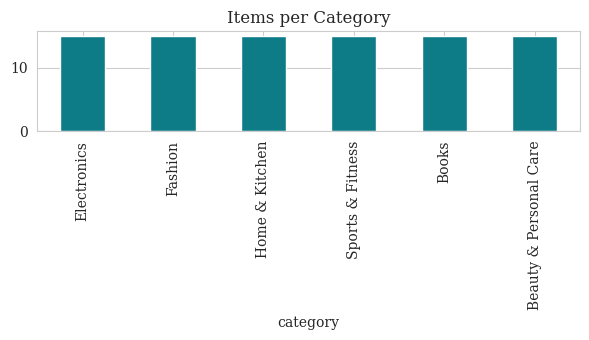

In [ ]:
print("Users:", ratings['user_id'].nunique(), " Items rated:", ratings['item_id'].nunique())
print("Average ratings per user:", round(ratings.groupby('user_id').size().mean(), 1))
items['category'].value_counts().plot.bar(figsize=(6,3.5), color='#0E7C86', title='Items per Category')
plt.tight_layout();
plt.savefig(
    "/content/drive/MyDrive/UIU_Project/Items_per_Category.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

## 2. Content-based filtering

Idea: represent each item by its text (tags/description), turn that into TF-IDF vectors, and recommend items whose vectors are most similar (cosine similarity) to an item the user already liked. This works well even for brand-new items with no ratings yet (no "cold start" problem for items).

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')
item_vectors = tfidf.fit_transform(items['description'])
print("TF-IDF matrix shape:", item_vectors.shape)

item_sim = cosine_similarity(item_vectors)
item_sim_df = pd.DataFrame(item_sim, index=items['item_id'], columns=items['item_id'])
item_sim_df.iloc[:5, :5]

TF-IDF matrix shape: (90, 131)


item_id,1001,1002,1003,1004,1005
item_id,,,,,
1001,1.000000,0.445401,0.224247,0.609600,0.431375
1002,0.445401,1.000000,0.131816,0.235525,0.707073
1003,0.224247,0.131816,1.000000,0.211595,0.127665
1004,0.609600,0.235525,0.211595,1.000000,0.228108
1005,0.431375,0.707073,0.127665,0.228108,1.000000


In [ ]:
def content_based_recommend(item_id, top_n=5):
    scores = item_sim_df.loc[item_id].drop(item_id).sort_values(ascending=False)
    top_ids = scores.head(top_n).index
    result = items[items['item_id'].isin(top_ids)][['item_id','title','category']].copy()
    result['similarity'] = scores.loc[top_ids].values
    return result.sort_values('similarity', ascending=False)

seed_item = items.iloc[0]
print("Because you viewed:", seed_item['title'], f"({seed_item['category']})\n")
content_based_recommend(seed_item['item_id'], top_n=5)

Because you viewed: Smart Electronics Collection 01 (Electronics)



,item_id,title,category,similarity
3,1004,Advanced Electronics Collection 04,Electronics,0.727293
6,1007,Essential Electronics Collection 07,Electronics,0.727293
9,1010,Pro Electronics Collection 10,Electronics,0.654409
10,1011,Smart Electronics Collection 11,Electronics,0.609600
12,1013,Wireless Electronics Collection 13,Electronics,0.501925


## 3. Collaborative filtering (user-based)

Idea: build a user×item ratings matrix, measure how similar users are to each other based on their rating patterns (cosine similarity), and recommend items that *similar users* rated highly but the target user has not yet rated. This works even when items have no text description — it only needs rating behavior.

In [ ]:
user_item = ratings.pivot_table(index='user_id', columns='item_id', values='rating')
print("User-item matrix shape:", user_item.shape)
user_item.iloc[:5, :8]

User-item matrix shape: (450, 90)


item_id,1001,1002,1003,1004,1005,1006,1007,1008
user_id,,,,,,,,
5001,5.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0
5002,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN
5003,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
5004,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN
5005,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN


In [ ]:
# Fill missing values with 0 for similarity computation
filled = user_item.fillna(0)

user_sim = cosine_similarity(filled)

user_sim_df = pd.DataFrame(
    user_sim,
    index=user_item.index,
    columns=user_item.index
)

def collaborative_recommend(user_id, top_n=5, k_neighbors=15):
    sims = (
        user_sim_df.loc[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(k_neighbors)
    )

    neighbor_ratings = user_item.loc[sims.index]

    # Weighted average of neighbors' ratings
    weighted = (
        neighbor_ratings.mul(sims, axis=0).sum()
        / sims.abs().sum()
    )

    already_rated = user_item.loc[user_id].dropna().index

    weighted = (
        weighted
        .drop(already_rated, errors='ignore')
        .dropna()
        .sort_values(ascending=False)
    )

    top_ids = weighted.head(top_n).index

    result = items[
        items['item_id'].isin(top_ids)
    ][['item_id', 'title', 'category']].copy()

    result['predicted_rating'] = weighted.loc[top_ids].values

    return result.sort_values(
        'predicted_rating',
        ascending=False
    )


# Use an actual user ID from the dataset
target_user = user_item.index[0]

print("Recommendations for user", target_user, "\n")

collaborative_recommend(
    target_user,
    top_n=5
)

Recommendations for user 5001 



,item_id,title,category,predicted_rating
10,1011,Smart Electronics Collection 11,Electronics,1.488013
33,1034,Smart Home & Kitchen Collection 04,Home & Kitchen,1.196307
56,1057,Performance Sports & Fitness Collection 12,Sports & Fitness,1.042616
69,1070,Guide Books Collection 10,Books,0.920659
73,1074,Illustrated Books Collection 14,Books,0.920166


## 4. Evaluating the collaborative filtering model

In [ ]:
# Hold out 20% of ratings as a test set, predict them from a model trained on the rest
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train_df.pivot_table(index='user_id', columns='item_id', values='rating')
train_matrix = train_matrix.reindex(index=user_item.index, columns=user_item.columns)

# Mean-center before factorizing: fills gaps with the average rating instead of 0,
# so a "no rating" cell doesn't get treated as "rated this a 0" during factorization.
global_mean = train_df['rating'].mean()
train_centered = train_matrix.fillna(global_mean) - global_mean

svd = TruncatedSVD(n_components=20, random_state=42)
user_factors = svd.fit_transform(train_centered)
item_factors = svd.components_
pred_matrix = pd.DataFrame(np.dot(user_factors, item_factors), index=train_matrix.index, columns=train_matrix.columns) + global_mean
pred_matrix = pred_matrix.clip(1, 5)

y_true, y_pred = [], []
for _, row in test_df.iterrows():
    if row['user_id'] in pred_matrix.index and row['item_id'] in pred_matrix.columns:
        y_true.append(row['rating'])
        y_pred.append(pred_matrix.loc[row['user_id'], row['item_id']])

rmse = mean_squared_error(y_true, y_pred) ** 0.5
print(f"SVD collaborative filtering RMSE on held-out ratings: {rmse:.3f}  (n = {len(y_true)} test ratings)")
print(f"(For comparison, always predicting the global average rating {global_mean:.2f} gives RMSE = {mean_squared_error(y_true, [global_mean]*len(y_true))**0.5:.3f})")

SVD collaborative filtering RMSE on held-out ratings: 0.999  (n = 1038 test ratings)
(For comparison, always predicting the global average rating 3.88 gives RMSE = 0.986)


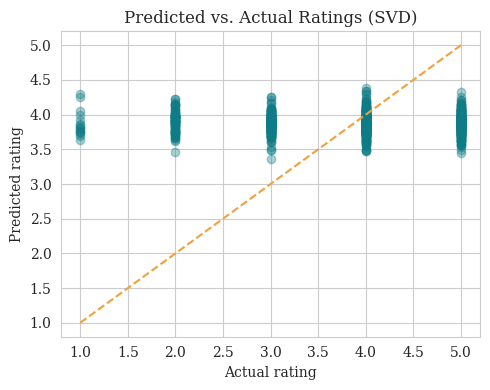

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(y_true, y_pred, alpha=0.35, color='#0E7C86')
plt.plot([1,5],[1,5],'--', color='#F2A03D')
plt.xlabel('Actual rating'); plt.ylabel('Predicted rating')
plt.title('Predicted vs. Actual Ratings (SVD)')
plt.tight_layout();
plt.savefig(
    "/content/drive/MyDrive/UIU_Project/Predicted vs Actual Ratings.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

## 5. Collaborative vs. content-based: side-by-side

| | Content-based | Collaborative |
|---|---|---|
| Uses | Item text/tags | User rating patterns |
| Needs a user history? | Works from a single liked item | Needs enough ratings to find similar users |
| New item ("item cold start") | Works immediately (has a description) | Cannot recommend until it has ratings |
| New user ("user cold start") | Needs at least one liked item | Cannot recommend until they rate something |
| Recommends surprising items? | Rarely — stays close to known interests | Can surprise — based on what similar users liked |

In [ ]:
print("Content-based, from a Books item:")
book_item = items[items['category']=='Books'].iloc[0]
display(content_based_recommend(book_item['item_id'], top_n=3))

print("\nCollaborative, for the same user shown above:")
display(collaborative_recommend(target_user, top_n=3))

Content-based, from a Books item:


,item_id,title,category,similarity
63,1064,Illustrated Books Collection 04,Books,0.843196
66,1067,Beginner Books Collection 07,Books,0.736036
72,1073,Essential Books Collection 13,Books,0.733923



Collaborative, for the same user shown above:


,item_id,title,category,predicted_rating
56,1057,Performance Sports & Fitness Collection 12,Sports & Fitness,1.488013
69,1070,Guide Books Collection 10,Books,1.196307
73,1074,Illustrated Books Collection 14,Books,1.042616


## 6. Discussion prompts for class

- For user 1, do the content-based and collaborative recommendations point toward the same category? What does that tell you about this user's preferences?
- Why does content-based filtering fail to solve the "user cold start" problem, even though it solves the "item cold start" problem?
- The RMSE above measures rating *prediction* accuracy. Is a low RMSE the same thing as "good recommendations"? What else might you want to measure (e.g., precision@k, diversity, novelty)?
- A real system (e.g., Amazon, Netflix) usually blends both approaches into a **hybrid recommender**. Sketch, in one sentence, how you might combine the two similarity scores above into one ranked list.

These are exactly the kinds of questions your **Collaborative vs. Content-Based Filtering** deliverable asks you to answer.